# Tema 2: base matemática de las redes neuronales



Veamos un ejemplo concreto de una red neuronal que utiliza la biblioteca de aprendizaje automático **Keras** para aprender a clasificar dígitos escritos a mano. Se trata de una biblioteca sencilla y de alto nivel que nos permitirá centrarnos en los conceptos que queremos tratar.

El problema que intentamos resolver aquí es clasificar imágenes en escala de grises de dígitos escritos a mano (28 × 28 píxeles) en sus 10 categorías (del 0 al 9). Usaremos el conjunto de datos **MNIST**, un clásico en la comunidad del aprendizaje automático, que existe casi desde los inicios de este campo y ha sido objeto de intensos estudios. Se trata de un conjunto de 60 000 imágenes de entrenamiento, más 10 000 imágenes de prueba, recopiladas por el Instituto Nacional de Estándares y Tecnología (el NIST en MNIST) en la década de 1980. Se puede considerar que «resolver» MNIST es como el «Hola mundo» del aprendizaje profundo: es lo que se hace para verificar que los algoritmos funcionan como se espera. A medida que te conviertas en un profesional del aprendizaje automático, verás que MNIST aparece una y otra vez en artículos científicos, entradas de blogs, etc.



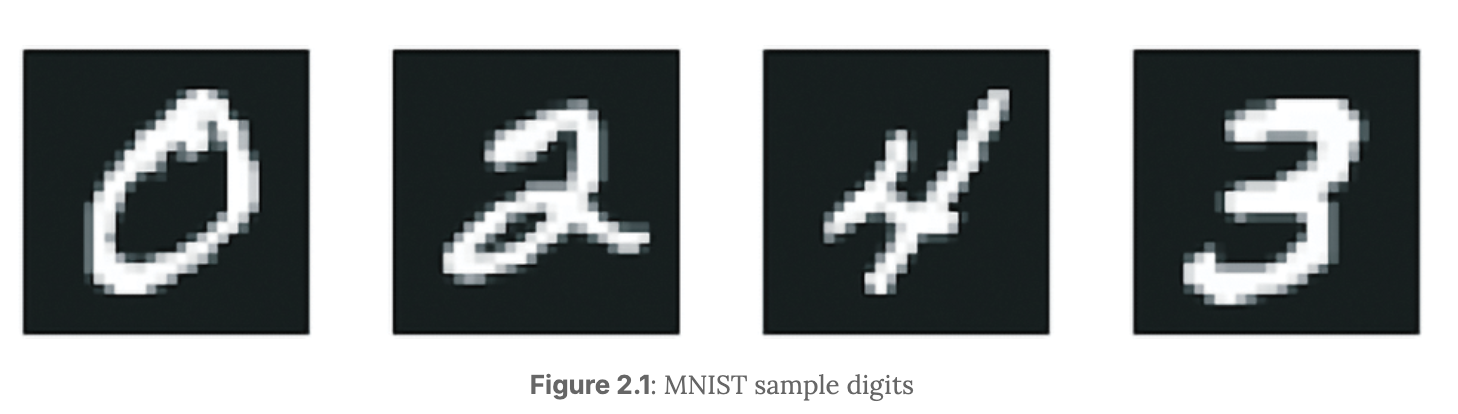

In [ ]:
from keras.datasets import mnist

(train_images, train_labels), (test_images, test_labels) = mnist.load_data()

train_images y train_labels forman el conjunto de entrenamiento, los datos a partir de los cuales aprenderá el modelo. A continuación, el modelo se pondrá a prueba en el conjunto de prueba, test_images y test_labels. Las imágenes se codifican como matrices NumPy y las etiquetas son una matriz de dígitos que van del 0 al 9. Las imágenes y las etiquetas tienen una correspondencia uno a uno.

In [ ]:
print(train_images.shape)
print(len(train_labels))
print(train_labels)

In [ ]:
print(test_images.shape, len(test_labels), test_labels)


El flujo de trabajo será el siguiente.

Primero, alimentaremos la red neuronal con los datos de entrenamiento, train_images y train_labels.

A continuación, la red aprenderá a asociar imágenes y etiquetas.

Por último, le pediremos a la red que genere predicciones para test_images y verificaremos si estas predicciones coinciden con las etiquetas de test_labels.

Construyamos la red. Recuerda que no es necesario que entiendas todo sobre este ejemplo todavía.

In [ ]:
import keras
from keras import layers

model = keras.Sequential(
    [
        layers.Dense(512, activation="relu"),
        layers.Dense(10, activation="softmax"),
    ]
)

El componente básico de las redes neuronales es la capa.

Se puede considerar una capa como un filtro para los datos: algunos datos entran y salen en una forma más útil. Concretamente, las capas extraen representaciones de los datos que se les introducen, con la esperanza de que sean representaciones más significativas para el problema en cuestión.

La mayor parte del aprendizaje profundo consiste en encadenar capas simples que implementarán una forma de destilación progresiva de datos. Un modelo de aprendizaje profundo es como un tamiz para el procesamiento de datos, compuesto por una sucesión de filtros de datos cada vez más refinados: las capas.

En este caso, nuestro modelo consiste en una secuencia de dos capas densas, que son capas neuronales densamente conectadas (también llamadas totalmente conectadas).

La segunda (y última) capa es una capa de clasificación softmax de 10 vías, lo que significa que devolverá una matriz de 10 puntuaciones de probabilidad (que suman 1). Cada puntuación será la probabilidad de que la imagen del dígito actual pertenezca a una de nuestras 10 clases de dígitos.

Para que el modelo esté listo para el entrenamiento, necesitamos elegir tres cosas más, como parte del paso de compilación:

Una función de pérdida: cómo el modelo podrá medir su rendimiento con los datos de entrenamiento y, por lo tanto, cómo podrá orientarse en la dirección correcta.

Un optimizador: el mecanismo mediante el cual el modelo se actualizará a sí mismo basándose en los datos de entrenamiento que ve, para mejorar su rendimiento.

Métricas que se deben supervisar durante el entrenamiento y las pruebas: aquí solo nos preocuparemos por la precisión (la fracción de imágenes que se clasificaron correctamente).

In [ ]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

Antes del entrenamiento, preprocesaremos los datos remodelándolos a la forma que espera el modelo y escalándolos para que todos los valores estén en el intervalo [0, 1]. Anteriormente, nuestras imágenes de entrenamiento se almacenaban en una matriz de forma (60000, 28, 28) de tipo uint8 con valores en el intervalo [0, 255]. Las transformamos en una matriz float32 de forma (60000, 28 * 28) con valores entre 0 y 1.

In [ ]:
train_images = train_images.reshape((60000, 28 * 28))
train_images = train_images.astype("float32") / 255
test_images = test_images.reshape((10000, 28 * 28))
test_images = test_images.astype("float32") / 255

Ahora estamos listos para entrenar el modelo, lo que en Keras se hace mediante una llamada al método fit() del modelo: ajustamos el modelo a sus datos de entrenamiento.



In [ ]:
model.fit(train_images, train_labels, epochs=5, batch_size=128)


Durante el entrenamiento se muestran dos magnitudes: la pérdida del modelo sobre los datos de entrenamiento y la precisión del modelo sobre los datos de entrenamiento. Rápidamente alcanzamos una precisión de 0,989 (98,9 %) en los datos de entrenamiento.

Ahora que tenemos un modelo entrenado, podemos utilizarlo para predecir las probabilidades de clase para nuevos dígitos, es decir, imágenes que no formaban parte de los datos de entrenamiento, como las del conjunto de prueba.

In [ ]:
test_digits = test_images[0:10]
predictions = model.predict(test_digits)
predictions[0]

Cada número del índice i en esa matriz corresponde a la probabilidad de que la imagen del dígito test_digits[0] pertenezca a la clase i.

Este primer dígito de prueba tiene la puntuación de probabilidad más alta (0,99999106, casi 1) en el índice 7, por lo que, según nuestro modelo, debe ser un 7:

In [ ]:
print(predictions[0].argmax(), predictions[0][7])


In [ ]:
test_labels[0]


En promedio, ¿qué tan bueno es nuestro modelo para clasificar dígitos nunca antes vistos? Comprobémoslo calculando la precisión promedio en todo el conjunto de pruebas.



In [ ]:
test_loss, test_acc = model.evaluate(test_images, test_labels)
print(f"test_acc: {test_acc}")

La precisión del conjunto de pruebas resulta ser del 97,8 %, casi el doble de la tasa de error del conjunto de entrenamiento (con una precisión del 98,9 %). Esta diferencia entre la precisión del entrenamiento y la precisión de las pruebas es un ejemplo de sobreajuste: el hecho de que los modelos de aprendizaje automático tienden a funcionar peor con datos nuevos que con los datos de entrenamiento.

## Tensores

En el ejemplo anterior, partimos de datos almacenados en matrices NumPy multidimensionales, también llamadas tensores. En general, todos los sistemas actuales de aprendizaje automático utilizan tensores como estructura de datos básica. Los tensores son fundamentales en este campo, tan fundamentales que el marco TensorFlow recibió su nombre en honor a ellos. Entonces, ¿qué es un tensor?

En esencia, un tensor es un contenedor de datos, normalmente datos numéricos. Es decir, es un contenedor de números. Es posible que ya esté familiarizado con las matrices, que son tensores de rango 2: los tensores son una generalización de las matrices a un número arbitrario de dimensiones (tenga en cuenta que, en el contexto de los tensores, una dimensión se denomina a menudo eje).

Repasar los detalles de los tensores puede parecer un poco abstracto al principio. Pero merece la pena: la manipulación de tensores será el pan de cada día de cualquier código de aprendizaje automático que escriba.

### Escalares

Un tensor que contiene solo un número se denomina escalar (o tensor escalar, tensor de rango 0 o tensor 0D). En NumPy, un número float32 o float64 es un tensor escalar (o matriz escalar). Se puede mostrar el número de ejes de un tensor NumPy mediante el atributo ndim; un tensor escalar tiene 0 ejes (ndim == 0). El número de ejes de un tensor también se denomina rango. A continuación se muestra un escalar NumPy.

In [ ]:
import numpy as np
x = np.array(12)
print(x, x.ndim)

### Vectores

Una matriz de números se denomina vector (o tensor de rango 1 o tensor 1D). Un tensor de rango 1 tiene exactamente un eje. El siguiente es un vector NumPy:

In [ ]:
x = np.array([12, 3, 6, 14, 7])
print(x, x.ndim)

Este vector tiene cinco entradas, por lo que se denomina vector de 5 dimensiones.

¡No confundas un vector 5D con un tensor 5D!

Un vector 5D solo tiene un eje y cinco dimensiones a lo largo de su eje, mientras que un tensor 5D tiene cinco ejes (y puede tener cualquier número de dimensiones a lo largo de cada eje). La dimensionalidad puede denotar tanto el número de entradas a lo largo de un eje específico (como en el caso de nuestro vector 5D) como el número de ejes en un tensor (como un tensor 5D), lo que a veces puede resultar confuso. En este último caso, técnicamente es más correcto hablar de un tensor de rango 5 (el rango de un tensor es el número de ejes), pero la notación ambigua «tensor 5D» es común independientemente de ello.

### Matrices

Una matriz de vectores es una matriz (o tensor de rango 2 o tensor 2D).
Una matriz tiene dos ejes (a menudo denominados filas y columnas).
Se puede interpretar visualmente una matriz como una cuadrícula rectangular de números. Esta es una matriz NumPy:

In [ ]:
x = np.array([[5, 78, 2, 34, 0],
...           [6, 79, 3, 35, 1],
...           [7, 80, 4, 36, 2]])
x.ndim

Las entradas del primer eje se denominan filas, y las entradas del segundo eje se denominan columnas. En el ejemplo anterior, [5, 78, 2, 34, 0] es la primera fila de x, y [5, 6, 7] es la primera columna.

### Tensores de rango 3 o superior

Si empaquetas estas matrices en una nueva matriz, obtienes un tensor de rango 3 (o tensor 3D), que puedes interpretar visualmente como un cubo de números. El siguiente es un tensor NumPy de rango 3:



In [ ]:
x = np.array([[[5, 78, 2, 34, 0],
...                [6, 79, 3, 35, 1],
...                [7, 80, 4, 36, 2]],
...               [[5, 78, 2, 34, 0],
...                [6, 79, 3, 35, 1],
...                [7, 80, 4, 36, 2]],
...               [[5, 78, 2, 34, 0],
...                [6, 79, 3, 35, 1],
...                [7, 80, 4, 36, 2]]])
x.ndim

Al empaquetar tensores de rango 3 en una matriz, se puede crear un tensor de rango 4, y así sucesivamente. En el aprendizaje profundo, normalmente se manipulan tensores con rangos de 0 a 4, aunque se puede llegar hasta 5 si se procesan datos de vídeo.

### Elementos clave de tensores

Un tensor se define por tres atributos clave:

Número de ejes (rango): por ejemplo, un tensor de rango 3 tiene tres ejes y una matriz tiene dos ejes. Esto también se denomina ndim del tensor en bibliotecas Python como NumPy, JAX, TensorFlow y PyTorch.

Forma: es una tupla de números enteros que describe cuántas dimensiones tiene el tensor a lo largo de cada eje. Por ejemplo, la matriz del ejemplo anterior tiene la forma (3, 5), y el tensor de rango 3 tiene la forma (3, 3, 5). Un vector tiene una forma con un solo elemento, como (5,), mientras que un escalar tiene una forma vacía, ().

Tipo de datos (normalmente denominado dtype en las bibliotecas de Python) : es el tipo de datos que contiene el tensor; por ejemplo, el tipo de un tensor podría ser float16, float32, float64, uint8, bool, etc. En TensorFlow, también es probable que te encuentres con tensores de cadena.

Para que esto sea más concreto, repasemos los datos que procesamos en el ejemplo MNIST. Primero, cargamos el conjunto de datos MNIST:

In [ ]:
from keras.datasets import mnist

(train_images, train_labels), (test_images, test_labels) = mnist.load_data()

A continuación, mostramos el número de ejes del tensor train_images, el atributo ndim:


In [ ]:
train_images.ndim

su shape

In [ ]:
train_images.shape

y el tipo de datos que contiene

In [ ]:
train_images.dtype

Lo que tenemos aquí es un tensor de rango 3 de enteros de 8 bits. Más concretamente, es una matriz de 60 000 matrices de enteros de 28 × 28. Cada una de estas matrices es una imagen en escala de grises, con coeficientes entre 0 y 255.

Mostremos el cuarto dígito de este tensor de rango 3 utilizando la biblioteca Matplotlib.



In [ ]:
import matplotlib.pyplot as plt

digit = train_images[4]
plt.imshow(digit, cmap=plt.cm.binary)
plt.show()

Naturalmente, la etiqueta correspondiente es simplemente el número 9:


In [ ]:
train_labels[4]

## Manipulando tensores con numpy

En el ejemplo anterior, seleccionamos un dígito específico junto al primer eje utilizando la sintaxis train_images[i]. La selección de elementos específicos en un tensor se denomina corte de tensor. Veamos las operaciones de corte de tensor que se pueden realizar en matrices NumPy.

El siguiente ejemplo selecciona los dígitos del 10 al 100 (sin incluir el 100) y los coloca en una matriz de forma (90, 28, 28):

In [ ]:
my_slice = train_images[10:100]
my_slice.shape

Es equivalente a esta notación más detallada, que especifica un índice inicial y un índice final para el corte a lo largo de cada eje del tensor. Tenga en cuenta que : es equivalente a seleccionar todo el eje:



In [ ]:
my_slice = train_images[10:100, :, :]
my_slice.shape

In [ ]:
my_slice = train_images[10:100, 0:28, 0:28]
my_slice.shape

En general, puede seleccionar secciones entre dos índices cualesquiera a lo largo de cada eje del tensor. Por ejemplo, para seleccionar 14 × 14 píxeles en la esquina inferior derecha de todas las imágenes, haría lo siguiente:



In [ ]:
my_slice = train_images[:, 14:, 14:]

También es posible utilizar índices negativos. Al igual que los índices negativos en las listas de Python, indican una posición relativa al final del eje actual. Para recortar las imágenes en fragmentos de 14 × 14 píxeles centrados en el medio, haz lo siguiente:



In [ ]:
my_slice = train_images[:, 7:-7, 7:-7]

## El concepto de batch

En general, el primer eje (eje 0, ya que la indexación comienza en 0) en todos los tensores de datos que encontrarás en el aprendizaje profundo será el eje de muestras. En el ejemplo MNIST, las «muestras» son imágenes de dígitos.

Además, los modelos de aprendizaje profundo no procesan todo un conjunto de datos de una sola vez, sino que dividen los datos en pequeños «lotes» o grupos de muestras con un tamaño fijo. Concretamente, aquí hay un lote de nuestros dígitos MNIST, con un tamaño de lote de 128:

In [ ]:
batch = train_images[:128]

Siguiente batch

In [ ]:
batch = train_images[128:256]

Para tener el batch n

In [ ]:
n = 3
batch = train_images[128 * n : 128 * (n + 1)]

Al considerar un tensor por lotes de este tipo, el primer eje (eje 0) se denomina eje por lotes (o dimensión por lotes). Este término aparece con frecuencia al utilizar Keras y otras bibliotecas de aprendizaje profundo.

## Ejemplos reales de tensores


Hagamos que los tensores de datos sean más concretos con algunos ejemplos similares a los que encontrarás más adelante. Los datos que manipularás casi siempre se clasificarán en una de las siguientes categorías:

Datos vectoriales: tensores de rango 2 con forma (muestras, características), donde cada muestra es un vector de atributos numéricos («características»).

Datos de series temporales o datos de secuencias: tensores de rango 3 con forma (muestras, intervalos de tiempo, características), donde cada muestra es una secuencia (de longitud intervalos de tiempo) de vectores de características.

Imágenes: tensores de rango 4 con forma (muestras, altura, anchura, canales), donde cada muestra es una cuadrícula 2D de píxeles y cada píxel está representado por un vector de valores («canales»).

Vídeo: tensores de rango 5 con forma (muestras, fotogramas, altura, anchura, canales), donde cada muestra es una secuencia (de longitud fotogramas) de imágenes.

### Datos vectoriales

Los datos vectoriales son uno de los casos más comunes. En un conjunto de datos de este tipo, cada punto de datos individual puede codificarse como un vector, por lo que un lote de datos se codificará como un tensor de rango 2 (es decir, una matriz de vectores), donde el primer eje es el eje de muestras y el segundo eje es el eje de características.

Veamos dos ejemplos:

Un conjunto de datos actuariales de personas, en el que se tiene en cuenta la edad, el sexo y los ingresos de cada persona. Cada persona puede caracterizarse como un vector de tres valores, por lo que un conjunto de datos completo de 100 000 personas puede almacenarse en un tensor de rango 2 de forma (100000, 3).

Un conjunto de datos de documentos de texto, en el que representamos cada documento por el número de veces que aparece cada palabra en él (de un diccionario de 20 000 palabras comunes). Cada documento puede codificarse como un vector de 20 000 valores (un recuento por palabra del diccionario) y, por lo tanto, un conjunto de datos completo de 500 documentos puede almacenarse en un tensor de forma (500, 20000).

### Datos de series temporales o datos secuenciales


Siempre que el tiempo sea importante en sus datos (o la noción de orden secuencial), tiene sentido almacenarlos en un tensor de rango 3 con un eje temporal explícito. Cada muestra se puede codificar como una secuencia de vectores (un tensor de rango 2) y, por lo tanto, un lote de datos se codificará como un tensor de rango 3

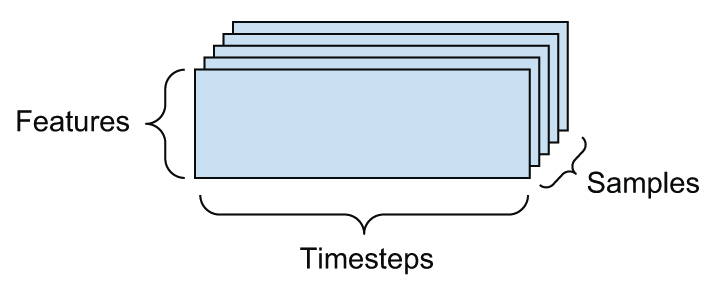

El eje temporal es siempre el segundo eje (eje del índice 1), por convención. Veamos algunos ejemplos:

Un conjunto de datos de precios de acciones: cada minuto, almacenamos el precio actual de la acción, el precio más alto del último minuto y el precio más bajo del último minuto. Así, cada minuto se codifica como un vector 3D, un día completo de negociación se codifica como una matriz de forma (390, 3) (hay 390 minutos en un día de negociación) y los datos de 250 días se pueden almacenar en un tensor de rango 3 de forma (250, 390, 3). En este caso, cada muestra sería los datos de un día.

Un conjunto de datos de tuits, en el que codificamos cada tuit como una secuencia de 280 caracteres de un alfabeto de 128 caracteres únicos. En esta configuración, cada carácter se puede codificar como un vector binario de tamaño 128 (un vector compuesto íntegramente por ceros, excepto por una entrada 1 en el índice correspondiente al carácter). Entonces, cada tuit se puede codificar como un tensor de rango 2 de forma (280, 128), y un conjunto de datos de 1 millón de tuits se puede almacenar en un tensor de forma (1000000, 280, 128).

### Datos de imagen

Las imágenes suelen tener tres dimensiones: altura, anchura y profundidad de color. Aunque las imágenes en escala de grises (como nuestros dígitos MNIST) solo tienen un canal de color y, por lo tanto, podrían almacenarse en tensores de rango 2, por convención, los tensores de imagen son siempre de rango 3, con un canal de color unidimensional para las imágenes en escala de grises. Así, un lote de 128 imágenes en escala de grises de tamaño 256 × 256 podría almacenarse en un tensor de forma (128, 256, 256, 1), y un lote de 128 imágenes en color podría almacenarse en un tensor de forma (128, 256, 256, 3)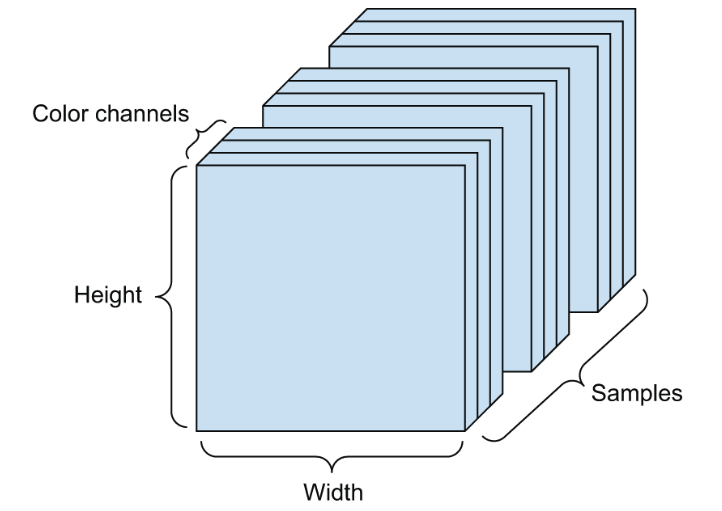

Existen dos convenciones para las formas de los tensores de imagen: la convención «canales al final» (que es la estándar en JAX y TensorFlow, así como en la mayoría de las demás herramientas de aprendizaje profundo que existen) y la convención «canales al principio» (que es la estándar en PyTorch).

La convención «canales al final» coloca el eje de profundidad de color al final: (muestras, altura, anchura, profundidad de color). Por su parte, la convención de canales primero coloca el eje de profundidad de color justo después del eje de lote: (muestras, profundidad_de_color, altura, anchura). Con la convención de canales primero, los ejemplos anteriores se convertirían en (128, 1, 256, 256) y (128, 3, 256, 256). La API de Keras es compatible con ambos formatos.

### Datos de vídeo

Los datos de vídeo son uno de los pocos tipos de datos del mundo real para los que se necesitan tensores de rango 5. Un vídeo puede entenderse como una secuencia de fotogramas, cada uno de los cuales es una imagen en color. Dado que cada fotograma se puede almacenar en un tensor de rango 3 (altura, anchura, profundidad de color), una secuencia de fotogramas se puede almacenar en un tensor de rango 4 (fotogramas, altura, anchura, profundidad de color) y, por lo tanto, un lote de diferentes vídeos se puede almacenar en un tensor de rango 5 de forma (muestras, fotogramas, altura, anchura, profundidad de color).

Por ejemplo, un videoclip de YouTube de 60 segundos, 144 × 256 y muestreado a 4 fotogramas por segundo tendría 240 fotogramas. Un lote de cuatro videoclips de este tipo se almacenaría en un tensor de forma (4, 240, 144, 256, 3). ¡Eso es un total de 106 168 320 valores! Si el tipo de datos del tensor fuera float32, cada valor se almacenaría en 32 bits, por lo que el tensor representaría 425 MB. ¡Pesado! Los vídeos que encontramos en la vida real son mucho más ligeros porque no se almacenan en float32 y suelen estar comprimidos en gran medida (por ejemplo, en formato MPEG).

## Operaciones entre tensores

Al igual que cualquier programa informático puede reducirse en última instancia a un pequeño conjunto de operaciones binarias sobre entradas binarias (AND, OR, NOR, etc.), todas las transformaciones aprendidas por las redes neuronales profundas pueden reducirse a un puñado de operaciones tensoriales (o funciones tensoriales) aplicadas a tensores de datos numéricos. Por ejemplo, es posible sumar tensores, multiplicar tensores, etc.

En nuestro ejemplo inicial, construimos nuestro modelo apilando capas densas unas encima de otras. Una instancia de capa Keras tiene este aspecto:

In [ ]:
keras.layers.Dense(512, activation="relu")

Esta capa puede interpretarse como una función que toma como entrada una matriz y devuelve otra matriz, una nueva representación del tensor de entrada. Concretamente, la función es la siguiente (donde W es una matriz y b es un vector, ambos atributos de la capa):

In [ ]:
output = relu(matmul(input, W) + b)

Analicemos esto. Aquí tenemos tres operaciones tensoriales:

Un producto tensorial (matmul) entre el tensor de entrada y un tensor denominado W.

Una suma (+) entre la matriz resultante y un vector b.

Una operación relu: relu(x) es max(x, 0). «relu» significa «unidad lineal rectificada».

## Operaciones por elementos

La operación relu y la suma son operaciones por elementos: operaciones que se aplican de forma independiente a cada entrada de los tensores considerados. Esto significa que estas operaciones son muy susceptibles de implementaciones masivamente paralelas (implementaciones vectorizadas, un término que proviene de la arquitectura de supercomputadoras con procesadores vectoriales del período 1970-1990). Si desea escribir una implementación ingenua en Python de una operación por elementos, utilice un bucle «for», como en esta implementación ingenua de una operación relu por elementos:

In [ ]:
def naive_relu(x):
    # x is a rank-2 NumPy tensor.
    assert len(x.shape) == 2
    # Avoids overwriting the input tensor
    x = x.copy()
    for i in range(x.shape[0]):
        for j in range(x.shape[1]):
            x[i, j] = max(x[i, j], 0)
    return x

Podrías hacer lo mismo para la suma:


In [ ]:
def naive_add(x, y):
    # x and y are rank-2 NumPy tensors.
    assert len(x.shape) == 2
    assert x.shape == y.shape
    # Avoids overwriting the input tensor
    x = x.copy()
    for i in range(x.shape[0]):
        for j in range(x.shape[1]):
            x[i, j] += y[i, j]
    return x

Siguiendo el mismo principio, se pueden realizar multiplicaciones, restas, etc., elemento por elemento.

En la práctica, cuando se trabaja con matrices NumPy, estas operaciones están disponibles como funciones NumPy integradas y bien optimizadas, que a su vez delegan el trabajo pesado a una implementación de subprogramas básicos de álgebra lineal (BLAS). Los BLAS son rutinas de manipulación de tensores de bajo nivel, altamente paralelas y eficientes que suelen implementarse en Fortran o C.

Por lo tanto, en NumPy, se pueden realizar las siguientes operaciones por elementos, y serán increíblemente rápidas:

In [ ]:
import numpy as np

# Element-wise addition
z = x + y
# Element-wise relu
z = np.maximum(z, 0.0)

Calculemos la diferencia de rapidez:


In [ ]:
import time

x = np.random.random((20, 100))
y = np.random.random((20, 100))

t0 = time.time()
for _ in range(1000):
    z = x + y
    z = np.maximum(z, 0.0)
print("Took: {0:.2f} s".format(time.time() - t0))

Esto tarda 0,02 segundos. Mientras tanto, la versión ingenua tarda la friolera de 2,45 segundos:



In [ ]:
t0 = time.time()
for _ in range(1000):
    z = naive_add(x, y)
    z = naive_relu(z)
print("Took: {0:.2f} s".format(time.time() - t0))

Del mismo modo, cuando se ejecuta código JAX/TensorFlow/PyTorch en una GPU, las operaciones por elementos se ejecutan mediante implementaciones CUDA totalmente vectorizadas que pueden aprovechar al máximo la arquitectura altamente paralela del chip de la GPU.

### Broadcasting

Nuestra implementación anterior de naive_add solo admite la suma de tensores de rango 2 con formas idénticas. Pero en la capa Dense introducida anteriormente, añadimos un tensor de rango 2 con un vector. ¿Qué ocurre con la suma cuando las formas de los dos tensores que se suman son diferentes?

Cuando sea posible, y si no hay ambigüedad, el tensor más pequeño se difundirá para que coincida con la forma del tensor más grande. La difusión (broadcasting) consta de dos pasos:

Se añaden ejes (denominados ejes de difusión) al tensor más pequeño para que coincida con la dimensión ndim del tensor más grande.

El tensor más pequeño se repite junto con estos nuevos ejes para que coincida con la forma completa del tensor más grande.
Veamos un ejemplo concreto. Consideremos X con forma (32, 10) e y con forma (10,):

In [ ]:
import numpy as np

# X is a random matrix with shape (32, 10).
X = np.random.random((32, 10))
# y is a random vector with shape (10,).
y = np.random.random((10,))

Primero, añadimos un primer eje vacío a y, cuya forma pasa a ser (1, 10):

In [ ]:
# The shape of y is now (1, 10).
y = np.expand_dims(y, axis=0)

A continuación, repetimos y 32 veces a lo largo de este nuevo eje, de modo que obtenemos un tensor Y con forma (32, 10), donde Y[i, :] == y para i en el rango (0, 32):

In [ ]:
# Repeat y 32 times along axis 0 to obtain Y with shape (32, 10).
Y = np.tile(y, (32, 1))

En este punto, podemos sumar X e Y porque tienen la misma forma.

En términos de implementación, no se crea ningún tensor de rango 2 nuevo porque eso sería tremendamente ineficiente. La operación de repetición es totalmente virtual: se produce a nivel algorítmico y no a nivel de memoria. Pero pensar en el vector repitiéndose 32 veces junto con un nuevo eje es un modelo mental útil. Así es como se vería una implementación ingenua:

In [ ]:
def naive_add_matrix_and_vector(x, y):
    # x is a rank-2 NumPy tensor.
    assert len(x.shape) == 2
    # y is a NumPy vector.
    assert len(y.shape) == 1
    assert x.shape[1] == y.shape[0]
    # Avoids overwriting the input tensor
    x = x.copy()
    for i in range(x.shape[0]):
        for j in range(x.shape[1]):
            x[i, j] += y[j]
    return x

Con la difusión, generalmente se pueden aplicar operaciones elemento por elemento con dos tensores si uno tiene forma (a, b, … n, n + 1, … m) y el otro tiene forma (n, n + 1, … m). La difusión se producirá automáticamente para los ejes a hasta n - 1.

En el siguiente ejemplo se aplica la operación elemento por elemento máxima a dos tensores de formas diferentes mediante la difusión:

In [ ]:
import numpy as np

# x is a random tensor with shape (64, 3, 32, 10).
x = np.random.random((64, 3, 32, 10))
# y is a random tensor with shape (32, 10).
y = np.random.random((32, 10))
# The output z has shape (64, 3, 32, 10) like x.
z = np.maximum(x, y)

## Producto tensorial

El producto tensorial, también llamado producto escalar o matmul (abreviatura de «multiplicación de matrices»), es una de las operaciones tensoriales más comunes y útiles.

En NumPy, el producto tensorial se realiza mediante la función np.matmul, y en Keras, con la función keras.ops.matmul. Su abreviatura es el operador @ en Python:

In [ ]:
x = np.random.random((32,))
y = np.random.random((32,))

# Takes the product between x and y
z = np.matmul(x, y)
# This is equivalent.
z = x @ y

En notación matemática, se indicaría la operación con un punto (•) (de ahí el nombre «producto escalar»):

In [ ]:
z = x • y

Matemáticamente, ¿qué hace la operación matmul? Comencemos con el producto de dos vectores x e y. Se calcula de la siguiente manera:



In [ ]:
def naive_vector_product(x, y):
    # x and y are NumPy vectors.
    assert len(x.shape) == 1
    assert len(y.shape) == 1
    assert x.shape[0] == y.shape[0]
    z = 0.0
    for i in range(x.shape[0]):
        z += x[i] * y[i]
    return z

Habrás observado que el producto entre dos vectores es un escalar y que solo los vectores con el mismo número de elementos son compatibles para esta operación.

También puedes calcular el producto entre una matriz x y un vector y, lo que devuelve un vector cuyos coeficientes son los productos entre y y las filas de x. Se implementa de la siguiente manera:

In [ ]:
def naive_matrix_vector_product(x, y):
    # x is a NumPy matrix.
    assert len(x.shape) == 2
    # y is a NumPy vector.
    assert len(y.shape) == 1
    # The 1st dimension of x must equal the 0th dimension of y!
    assert x.shape[1] == y.shape[0]
    # This operation returns a vector of 0s with as many rows as x.
    z = np.zeros(x.shape[0])
    for i in range(x.shape[0]):
        for j in range(x.shape[1]):
            z[i] += x[i, j] * y[j]
    return z

También podrías reutilizar el código que escribimos anteriormente, que destaca la relación entre un producto matriz-vector y un producto vectorial:

In [ ]:
def naive_matrix_vector_product(x, y):
    z = np.zeros(x.shape[0])
    for i in range(x.shape[0]):
        z[i] = naive_vector_product(x[i, :], y)
    return z

Ten en cuenta que tan pronto como uno de los dos tensores tiene un ndim mayor que 1, matmul ya no es simétrico, lo que significa que matmul(x, y) no es lo mismo que matmul(y, x).

Por supuesto, un producto tensorial se generaliza a tensores con un número arbitrario de ejes. Las aplicaciones más comunes pueden ser el producto entre dos matrices. Se puede tomar el producto de dos matrices x e y (matmul(x, y)) si y solo si x.shape[1] == y.shape[0]. El resultado es una matriz con forma (x.shape[0], y.shape[1]), donde los coeficientes son los productos vectoriales entre las filas de x y las columnas de y. Aquí está la implementación ingenua:

In [ ]:
def naive_matrix_product(x, y):
    # x and y are NumPy matrices.
    assert len(x.shape) == 2
    assert len(y.shape) == 2
    # The 1st dimension of x must equal the 0th dimension of y!
    assert x.shape[1] == y.shape[0]
    # This operation returns a matrix of 0s with a specific shape.
    z = np.zeros((x.shape[0], y.shape[1]))
    # Iterates over the rows of x ...
    for i in range(x.shape[0]):
        # ... and over the columns of y.
        for j in range(y.shape[1]):
            row_x = x[i, :]
            column_y = y[:, j]
            z[i, j] = naive_vector_product(row_x, column_y)
    return z

Para comprender la compatibilidad de formas del producto vectorial, resulta útil visualizar los tensores de entrada y salida alineándolo

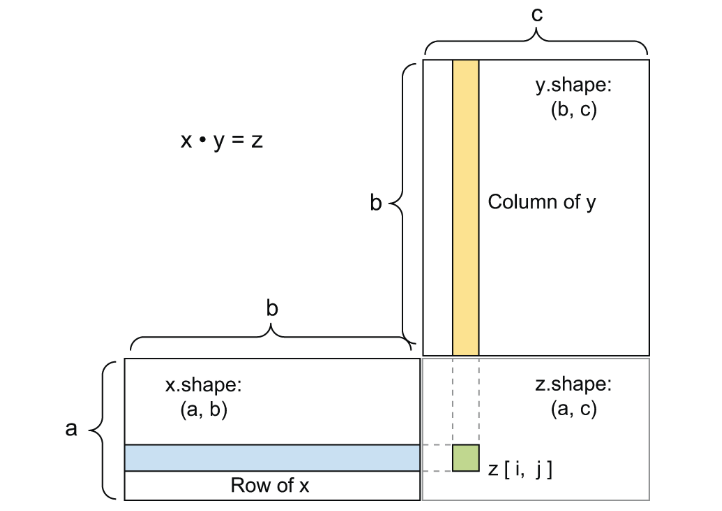

x, y y z se representan como rectángulos (cajas literales de coeficientes). Dado que las filas de x y las columnas de y deben tener el mismo tamaño, se deduce que la anchura de x debe coincidir con la altura de y. Si continúa desarrollando nuevos algoritmos de aprendizaje automático, es probable que dibuje este tipo de diagramas con frecuencia.

En términos más generales, puede tomar el producto entre tensores de dimensiones superiores, siguiendo las mismas reglas de compatibilidad de formas que se han descrito anteriormente para el caso 2D:


(a, b, c, d) • (d,) -> (a, b, c)
(a, b, c, d) • (d, e) -> (a, b, c, e)

## Reshaping de tensores


Un tercer tipo de operación tensorial que es esencial comprender es el reshaping de tensores. Aunque no se utilizó en las capas densas de nuestro primer ejemplo de red neuronal, la utilizamos cuando preprocesamos los datos numéricos antes de introducirlos en nuestro modelo:

In [ ]:
train_images = train_images.reshape((60000, 28 * 28))

Hacer reshaping a un tensor significa reorganizar sus filas y columnas para que coincidan con una forma objetivo. Naturalmente, el tensor reformado tiene el mismo número total de coeficientes que el tensor inicial. La reforma se entiende mejor mediante ejemplos sencillos:

In [ ]:
x = np.array([[0., 1.],
...               [2., 3.],
...               [4., 5.]])
print(x.shape)
x = x.reshape((6, 1))
print(x)
x = x.reshape((2, 3))
print(x)

Un caso especial de remodelación que se encuentra con frecuencia es la transposición. Transponer una matriz significa intercambiar sus filas y sus columnas, de modo que x[i, :] se convierte en x[:, i]:

In [ ]:
x = np.zeros((300, 20))
x = np.transpose(x)
x.shape

## Interpretación geométrica de las operaciones tensoriales

Dado que el contenido de los tensores manipulados por las operaciones tensoriales puede interpretarse como coordenadas de puntos en algún espacio geométrico, todas las operaciones tensoriales tienen una interpretación geométrica. Por ejemplo, consideremos la suma. Comenzaremos con el siguiente vector:


In [ ]:
A = [0.5, 1]

Es un punto en un espacio bidimensional, el cual es habitual representar como una flecha que une el origen con el punto.

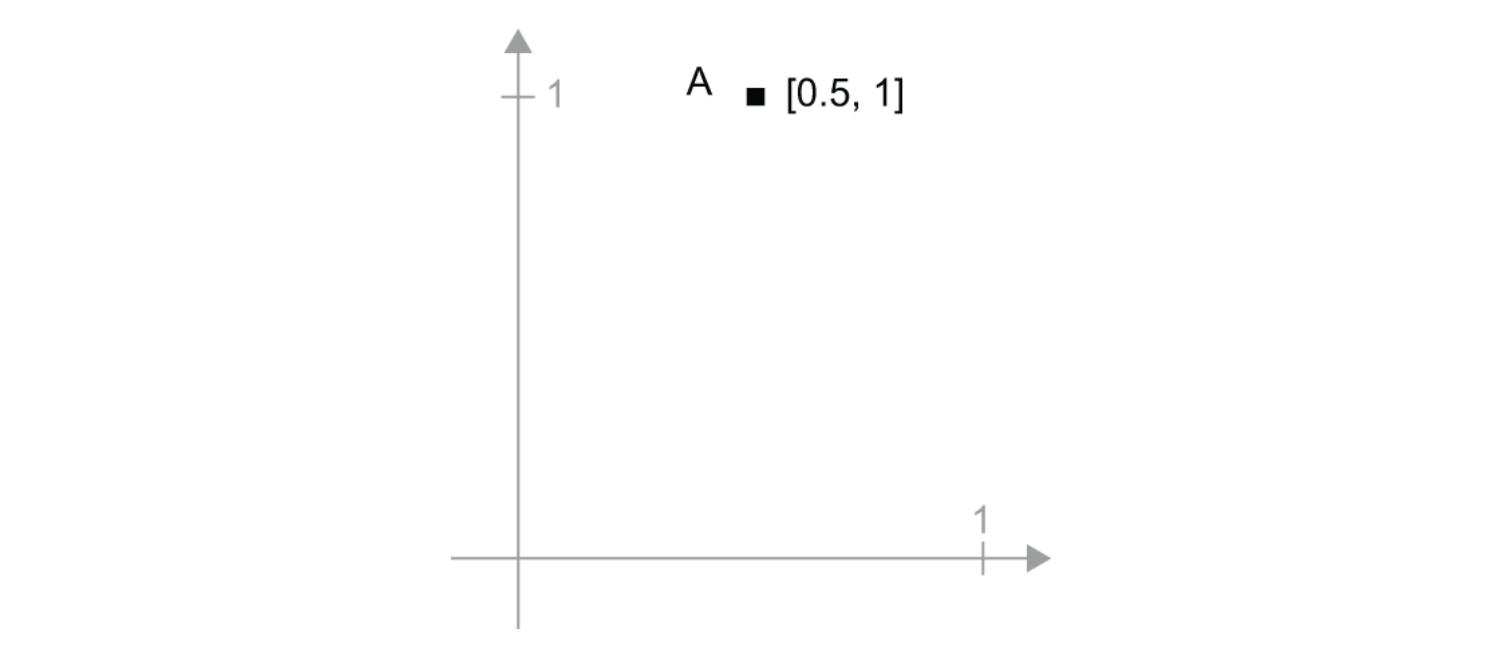

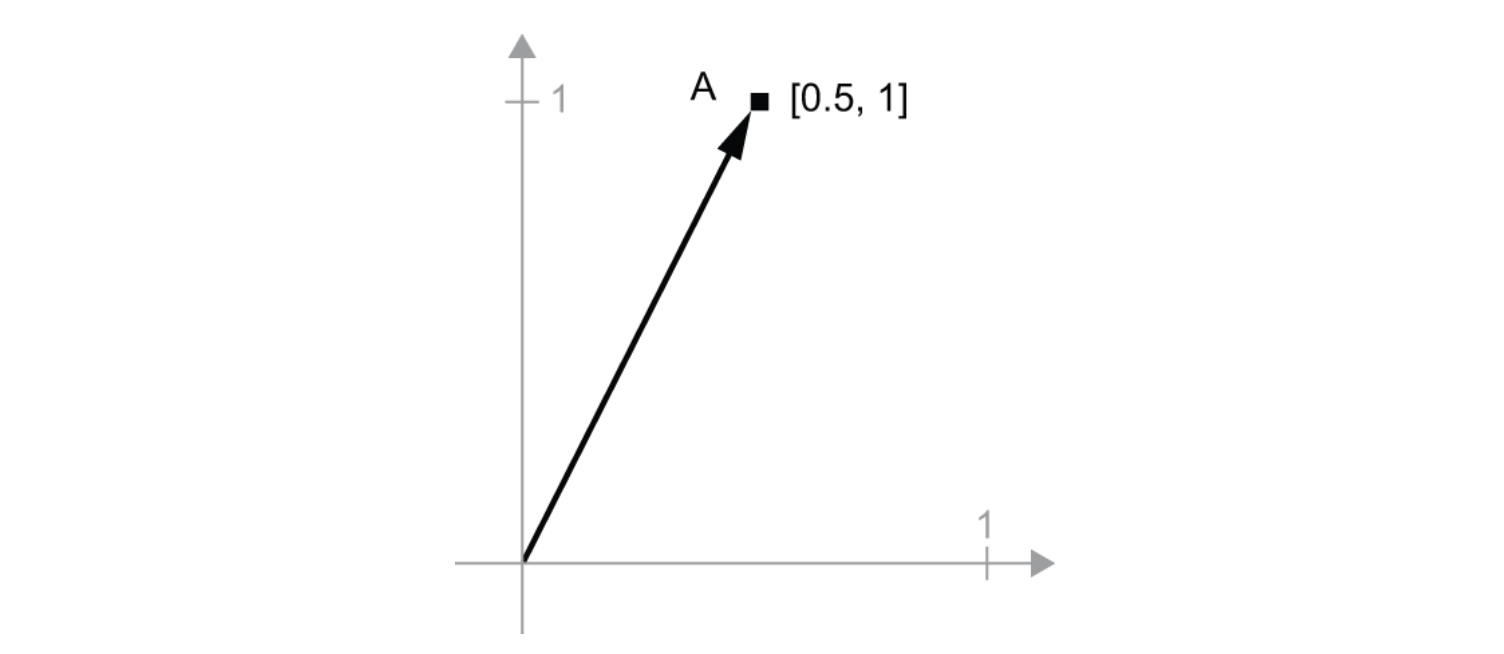


Consideremos un nuevo punto, B = [1, 0,25], que añadiremos al anterior. Esto se hace geométricamente encadenando las flechas de los vectores, siendo la ubicación resultante el vector que representa la suma de los dos vectores anteriores. Como se puede ver, añadir un vector B a un vector A representa la acción de copiar el punto A en una nueva ubicación, cuya distancia y dirección desde el punto original A viene determinada por el vector B. Si se aplica la misma suma vectorial a un grupo de puntos en el plano (un «objeto»), se crearía una copia de todo el objeto en una nueva ubicación. La suma tensorial representa, por tanto, la acción de trasladar un objeto (moverlo sin distorsionarlo) una cierta cantidad en una determinada dirección.

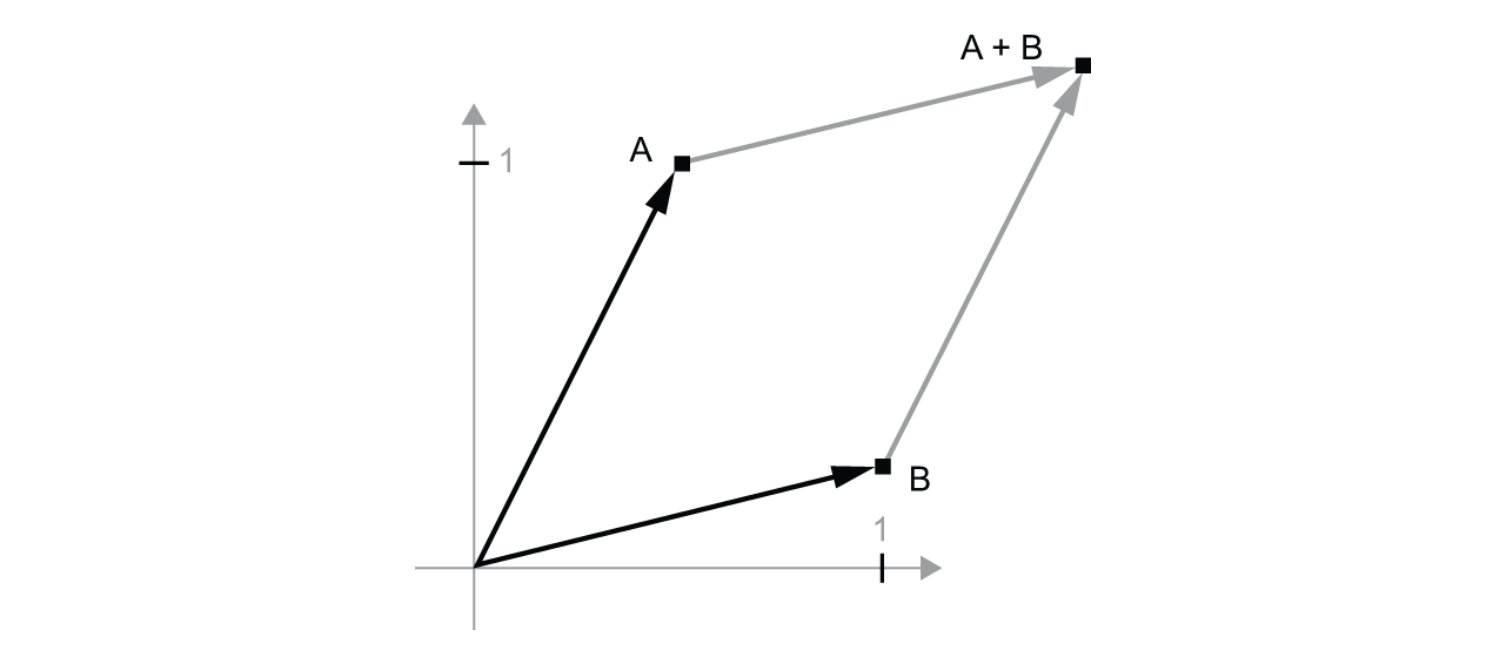



En general, las operaciones geométricas elementales, como la traslación, la rotación, el escalado, la inclinación, etc., pueden expresarse como operaciones tensoriales. A continuación se muestran algunos ejemplos:

Traslación: como acabamos de ver, al sumar un vector a un punto, este se desplazará una cantidad fija en una dirección fija. Cuando se aplica a un conjunto de puntos (como un objeto 2D), se denomina traslación

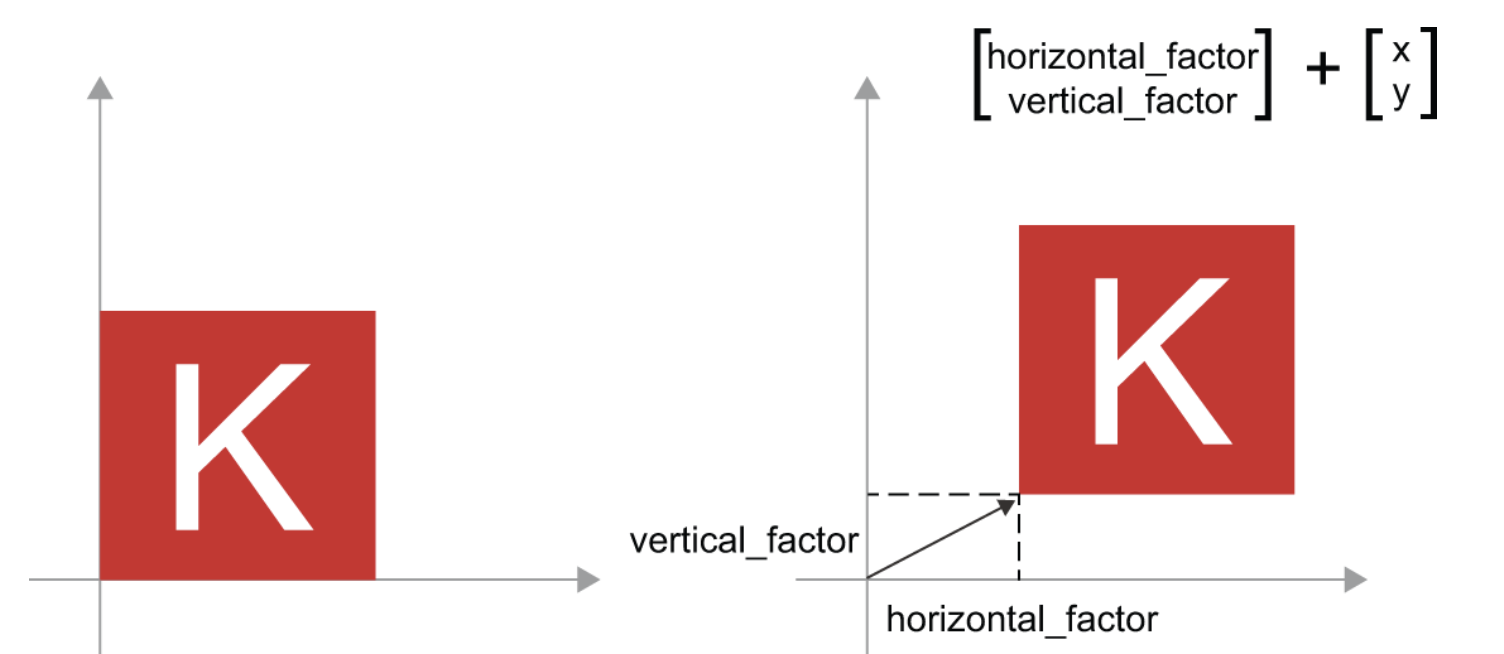

Rotación: una rotación en sentido antihorario de un vector 2D en un ángulo theta se puede lograr mediante un producto con una matriz 2 × 2 R = [[cos(theta), -sin(theta)], [sin(theta), cos(theta)]].


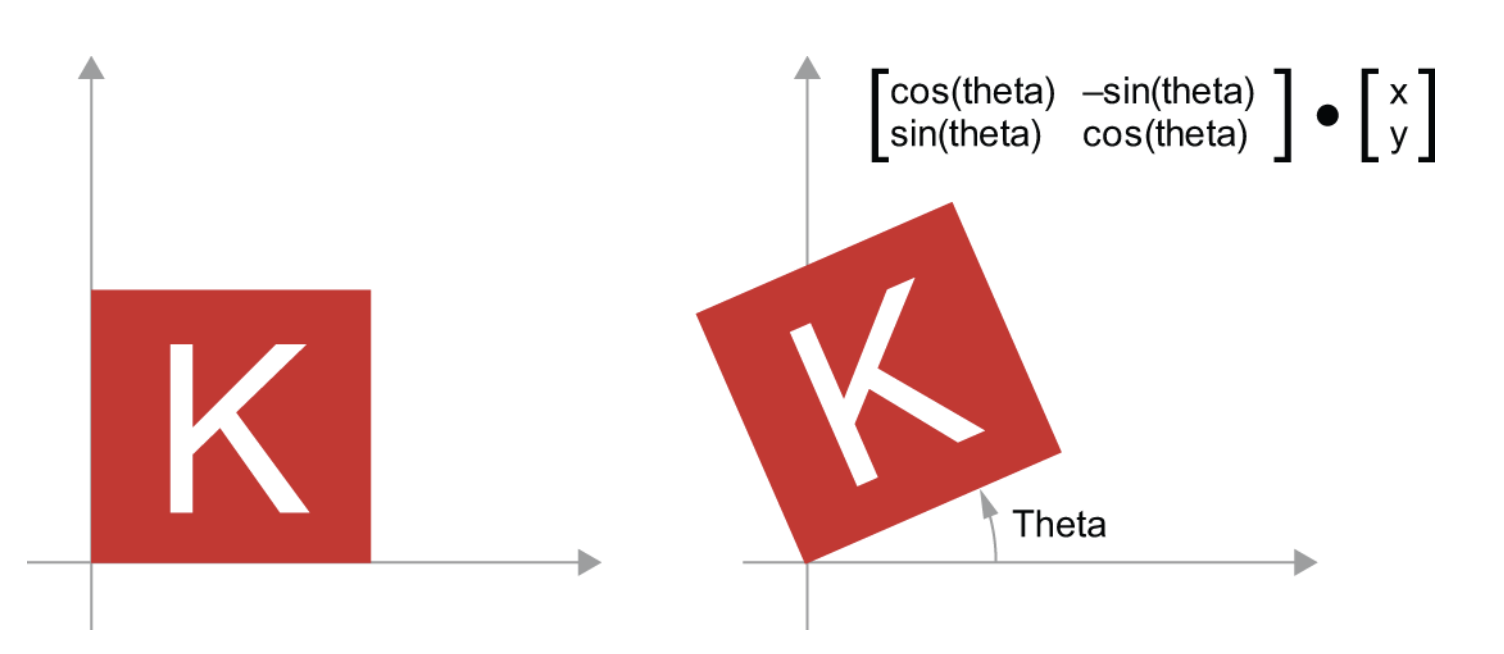


Escalado: se puede lograr un escalado vertical y horizontal de la imagen mediante un producto con una matriz 2 × 2 S = [[factor_horizontal, 0], [0, factor_vertical]] (tenga en cuenta que dicha matriz se denomina «matriz diagonal» porque solo tiene coeficientes distintos de cero en su «diagonal», que va desde la parte superior izquierda a la parte inferior derecha).


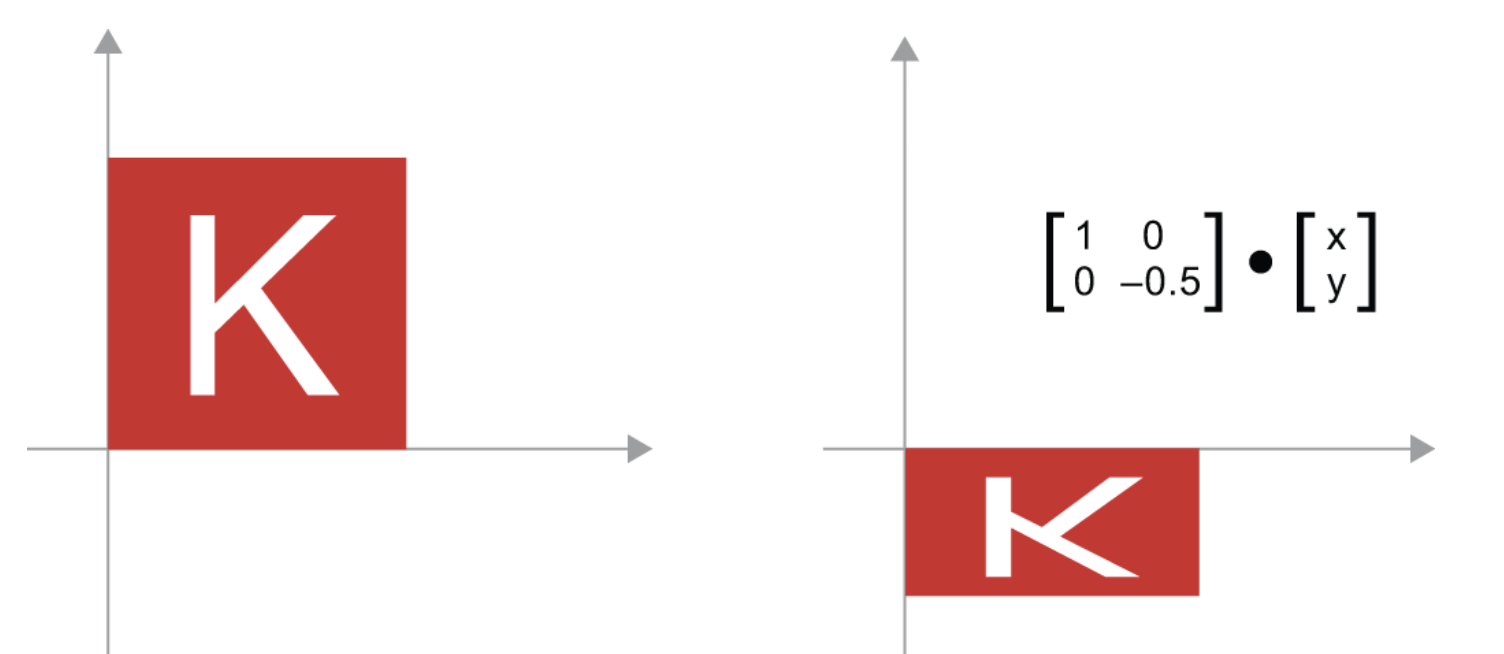


Transformación lineal: un producto con una matriz arbitraria implementa una transformación lineal. Tenga en cuenta que el escalado y la rotación, vistos anteriormente, son, por definición, transformaciones lineales.


Transformación afín: una transformación afín es la combinación de una transformación lineal (lograda mediante un producto matricial) y una traslación (lograda mediante una suma vectorial). Como probablemente habrá reconocido, ¡eso es exactamente el cálculo y = W @ x + b implementado por la capa Dense! Una capa Dense sin función de activación es una capa afín.


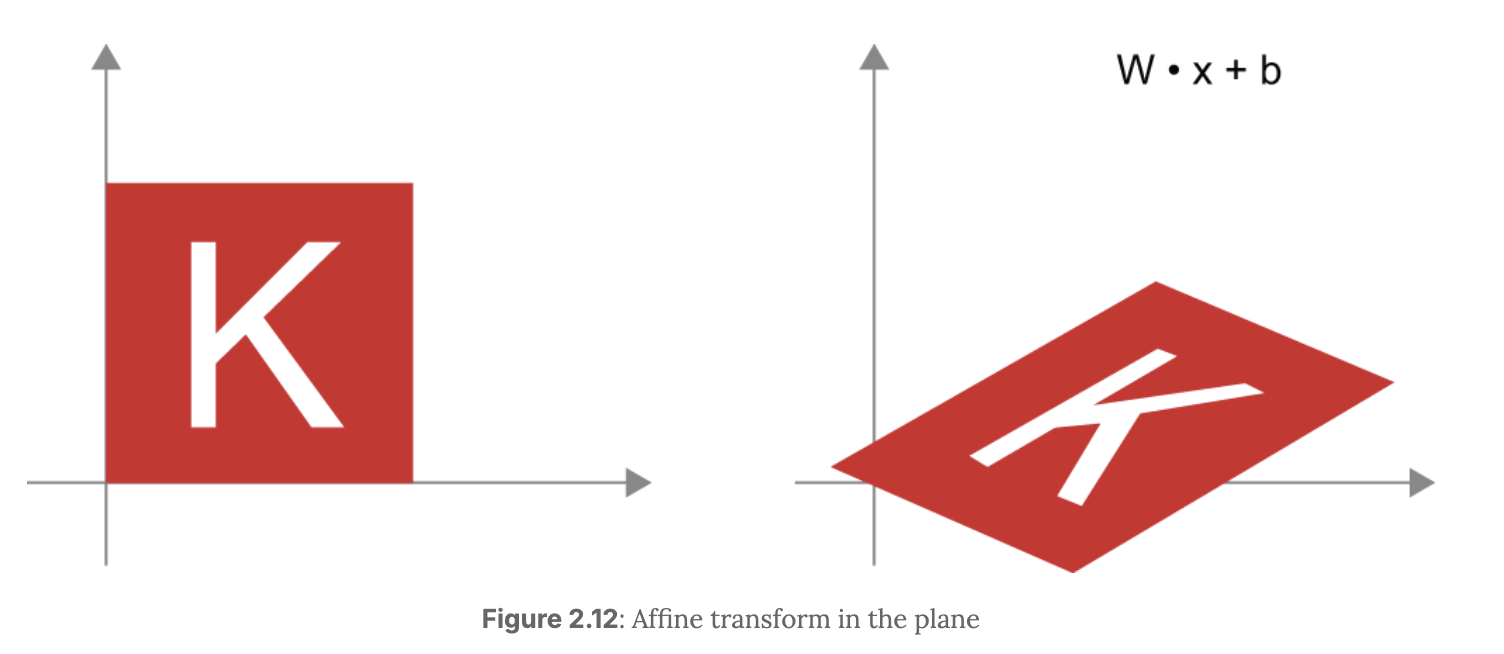


Capa densa con activación relu: una observación importante sobre las transformaciones afines es que, si se aplican muchas de ellas repetidamente, se obtiene una transformación afín (por lo que se podría haber aplicado esa única transformación afín desde el principio). Probémoslo con dos: afín2(afín1(x)) = W2 @ (W1 @ x + b1) + b2 = (W2 @ W1) @ x + (W2 @ b1 + b2). Se trata de una transformación afín en la que la parte lineal es la matriz W2 @ W1 y la parte de traslación es el vector W2 @ b1 + b2. Como consecuencia, una red neuronal multicapa compuesta íntegramente por capas densas sin activaciones sería equivalente a una sola capa densa. ¡Esta red neuronal «profunda» no sería más que un modelo lineal disfrazado! Por eso necesitamos funciones de activación, como relu. Gracias a las funciones de activación, se puede crear una cadena de capas densas para implementar transformaciones geométricas no lineales muy complejas, lo que da como resultado espacios de hipótesis muy ricos para sus redes neuronales profundas.

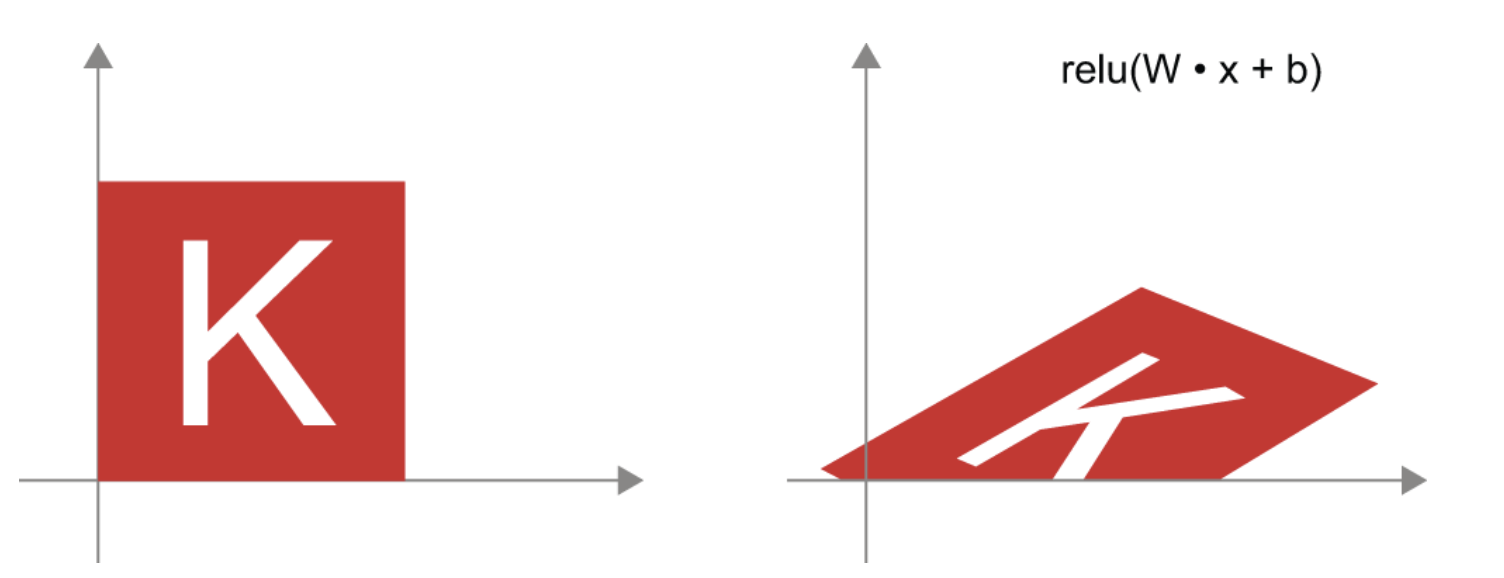

## Una interpretación geométrica del aprendizaje profundo


Acabas de aprender que las redes neuronales consisten enteramente en cadenas de operaciones tensoriales y que todas estas operaciones tensoriales son simples transformaciones geométricas de los datos de entrada. De ello se deduce que se puede interpretar una red neuronal como una transformación geométrica muy compleja en un espacio de alta dimensión, implementada mediante una serie de pasos sencillos.

En 3D, la siguiente imagen mental puede resultar útil. Imagina dos hojas de papel de colores: una roja y otra azul. Coloca una encima de la otra. Ahora arruga ambas hojas hasta formar una pequeña bola. Esa bola de papel arrugada son tus datos de entrada, y cada hoja de papel es una clase de datos en un problema de clasificación. Lo que se supone que debe hacer una red neuronal es averiguar una transformación de la bola de papel que la desarrugue para que las dos clases vuelvan a ser claramente separables. Con el aprendizaje profundo, esto se implementaría como una serie de transformaciones simples del espacio 3D, como las que se podrían aplicar a la bola de papel con los dedos, un movimiento cada vez.

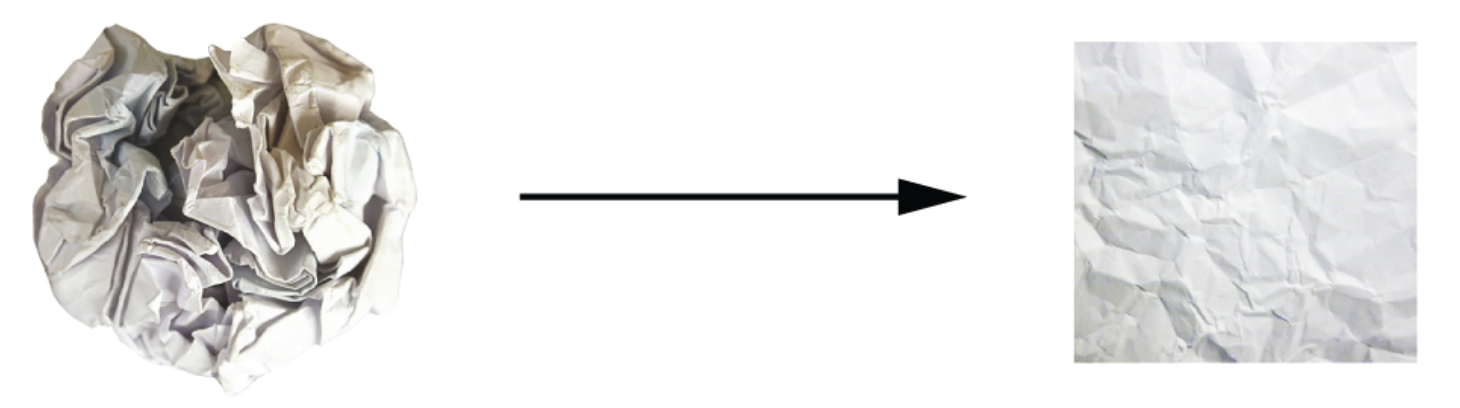


Desarrugar bolas de papel es de lo que se trata el aprendizaje automático: encontrar representaciones ordenadas para datos complejos y muy plegados en espacios de alta dimensión (una variedad es una superficie continua, como nuestra hoja de papel arrugada). Llegados a este punto, ya deberías tener una idea bastante clara de por qué el aprendizaje profundo destaca en esto: adopta el enfoque de descomponer gradualmente una transformación geométrica complicada en una larga cadena de transformaciones elementales, que es básicamente la estrategia que seguiría un humano para desarrugar una bola de papel. Cada capa de una red profunda aplica una transformación que desenreda un poco los datos, y una pila profunda de capas hace que un proceso de desenredado extremadamente complicado sea manejable.